# Análisis Exploratorio de Datos (EDA)
## Dataset: London Indian Takeaway Orders (Kaggle)

Este notebook realiza el análisis exploratorio del dataset seleccionado 
para el TFG de predicción de demanda en restauración con reparto a domicilio.

El dataset contiene pedidos reales de dos restaurantes de comida india 
para llevar ubicados en Londres, Reino Unido.

El objetivo es entender la estructura de los datos, detectar posibles 
problemas de calidad e identificar patrones temporales que justifiquen 
el uso de variables contextuales en el modelo predictivo, 
así como ayudar a seleccionar qué restaurante va a ser la base de estudio 
de este proyecto.

In [3]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de datos

Se cargan los ficheros de los dos restaurantes. 
Cada fichero contiene una línea por producto pedido, 
por lo que primero se cargan los datos 
completos y luego se agregan a nivel de pedido único.

In [4]:
# Carga de los datasets
r1 = pd.read_csv('../../data/raw/kaggle_london_indian_takeaway/restaurant-1-orders.csv')
r2 = pd.read_csv('../../data/raw/kaggle_london_indian_takeaway/restaurant-2-orders.csv')

# Convertir fechas
r1['Order Date'] = pd.to_datetime(r1['Order Date'], dayfirst=True)
r2['Order Date'] = pd.to_datetime(r2['Order Date'], dayfirst=True)

print(f"Restaurante 1: {r1.shape[0]} líneas de detalle")
print(f"Restaurante 2: {r2.shape[0]} líneas de detalle")
print(f"\nPedidos únicos R1: {r1['Order Number'].nunique()}")
print(f"Pedidos únicos R2: {r2['Order ID'].nunique()}")
print(f"\nTotal pedidos combinados: {r1['Order Number'].nunique() + r2['Order ID'].nunique()}")

Restaurante 1: 74818 líneas de detalle
Restaurante 2: 119183 líneas de detalle

Pedidos únicos R1: 13397
Pedidos únicos R2: 19658

Total pedidos combinados: 33055


### Observaciones
- El dataset contiene **33.055 pedidos reales** entre los dos restaurantes.
- Cada pedido puede contener varias líneas de detalle (productos distintos),
  lo que explica la diferencia entre líneas de detalle y pedidos únicos.
- Restaurante 1: 74.818 líneas para 13.397 pedidos (media de 5,6 productos por pedido).
- Restaurante 2: 119.183 líneas para 19.658 pedidos (media de 6,1 productos por pedido).

## 2. Estructura de los datos

In [5]:
# Primeras filas de cada restaurante
print("--- RESTAURANTE 1 ")
print(r1.head())
print()
print("--- RESTAURANTE 2 ")
print(r2.head())

--- RESTAURANTE 1 
   Order Number          Order Date            Item Name  Quantity  \
0         16118 2019-08-03 20:25:00        Plain Papadum         2   
1         16118 2019-08-03 20:25:00     King Prawn Balti         1   
2         16118 2019-08-03 20:25:00          Garlic Naan         1   
3         16118 2019-08-03 20:25:00        Mushroom Rice         1   
4         16118 2019-08-03 20:25:00  Paneer Tikka Masala         1   

   Product Price  Total products  
0           0.80               6  
1          12.95               6  
2           2.95               6  
3           3.95               6  
4           8.95               6  

--- RESTAURANTE 2 
   Order ID          Order Date             Item Name  Quantity  \
0     25583 2019-08-03 21:58:00  Tandoori Mixed Grill         1   
1     25583 2019-08-03 21:58:00          Madras Sauce         1   
2     25583 2019-08-03 21:58:00         Mushroom Rice         2   
3     25583 2019-08-03 21:58:00           Garlic Naan         

### Observaciones
- Ambos restaurantes tienen la misma estructura: una línea por producto 
  dentro de cada pedido.
- La columna `Order Date` contiene fecha y hora exacta de cada pedido.
- La columna `Total products` indica el número total de productos 
  en ese pedido, lo que permite identificar pedidos únicos fácilmente.
- Los productos son típicos de restaurante indio para llevar: 
  arroces, naans, currys y entrantes.

## 3. Calidad de los datos

Se analizan los valores nulos, duplicados y los tipos de datos 
para detectar problemas antes de construir el modelo.

In [6]:
print("--- RESTAURANTE 1 ")
print("Valores nulos:")
print(r1.isnull().sum())
print(f"\nDuplicados: {r1.duplicated().sum()}")

print("\n--- RESTAURANTE 2 ")
print("Valores nulos:")
print(r2.isnull().sum())
print(f"\nDuplicados: {r2.duplicated().sum()}")

--- RESTAURANTE 1 
Valores nulos:
Order Number      0
Order Date        0
Item Name         0
Quantity          0
Product Price     0
Total products    0
dtype: int64

Duplicados: 97

--- RESTAURANTE 2 
Valores nulos:
Order ID          0
Order Date        0
Item Name         0
Quantity          0
Product Price     0
Total products    0
dtype: int64

Duplicados: 178


### Observaciones
- **Sin valores nulos** en ninguna de las dos tablas.
- Se detectan **97 duplicados en el Restaurante 1** y **178 en el 
  Restaurante 2**, ambos representan menos del 0,2% del total de 
  registros y serán eliminados en el preprocesado.
- La calidad general de los datos es buena y permite pasar 
  directamente a la fase de análisis.

## 4. Preparación de la variable temporal

Se eliminan los duplicados y se agregan los datos a nivel de pedido 
único para construir la serie temporal de demanda diaria.

In [7]:
# Eliminar duplicados
r1_clean = r1.drop_duplicates()
r2_clean = r2.drop_duplicates()

# Agregar a nivel de pedido único
orders_r1 = r1_clean.groupby('Order Number').agg(
    datetime=('Order Date', 'first')
).reset_index()

orders_r2 = r2_clean.groupby('Order ID').agg(
    datetime=('Order Date', 'first')
).reset_index()

# Extraer variables temporales
for df in [orders_r1, orders_r2]:
    df['date'] = df['datetime'].dt.date
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.day_name()
    df['month'] = df['datetime'].dt.month

print(f"Pedidos R1 tras limpieza: {len(orders_r1)}")
print(f"Pedidos R2 tras limpieza: {len(orders_r2)}")
print(f"\nRango R1: {orders_r1['datetime'].min()} → {orders_r1['datetime'].max()}")
print(f"Rango R2: {orders_r2['datetime'].min()} → {orders_r2['datetime'].max()}")

Pedidos R1 tras limpieza: 13397
Pedidos R2 tras limpieza: 19658

Rango R1: 2015-09-01 14:42:00 → 2019-08-03 20:25:00
Rango R2: 2015-12-16 19:14:00 → 2019-08-03 21:58:00


### Observaciones
- Tras eliminar duplicados el número de pedidos no varía, lo que 
  confirma que los duplicados eran líneas de detalle repetidas, 
  no pedidos completos duplicados.
- **Restaurante 1** cubre casi **4 años** (septiembre 2015 - agosto 2019).
- **Restaurante 2** cubre casi **3,6 años** (diciembre 2015 - agosto 2019).

## 5. Análisis de patrones temporales

Para el análisis temporal se combinan los pedidos de ambos 
restaurantes en una única serie temporal.

### 5.1 Pedidos por día de la semana

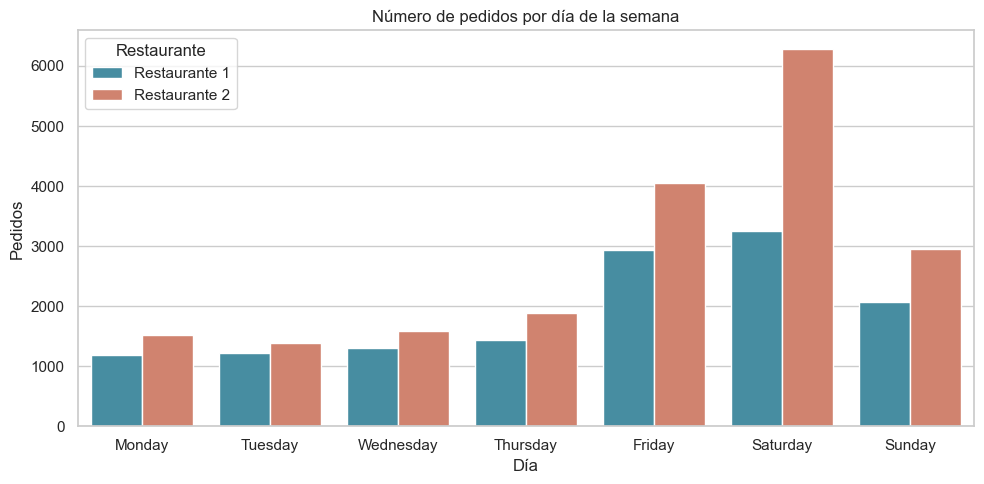

In [8]:
# Combinar los dos restaurantes añadiendo el identificador
orders_total = pd.concat([
    orders_r1[['datetime', 'date', 'hour', 'day_of_week', 'month']].assign(restaurant_id=1),
    orders_r2[['datetime', 'date', 'hour', 'day_of_week', 'month']].assign(restaurant_id=2)
], ignore_index=True)

# Contar pedidos por día de la semana y restaurante
pedidos_dia = (
    orders_total
    .groupby(['day_of_week', 'restaurant_id'])
    .size()
    .reset_index(name='n_pedidos')
)

# Ordenar los días
dias_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pedidos_dia['day_of_week'] = pd.Categorical(
    pedidos_dia['day_of_week'], 
    categories=dias_orden, 
    ordered=True
)
pedidos_dia = pedidos_dia.sort_values('day_of_week')

# Gráfica con barras agrupadas
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=pedidos_dia,
    x='day_of_week',
    y='n_pedidos',
    hue='restaurant_id',
    palette={1: '#3896b0', 2: '#e07a5f'},
    ax=ax
)
ax.set_title('Número de pedidos por día de la semana')
ax.set_xlabel('Día')
ax.set_ylabel('Pedidos')

# Leyenda con etiquetas legibles
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Restaurante 1', 'Restaurante 2'], title='Restaurante')

plt.tight_layout()
plt.savefig('../../notebooks/fig_london_pedidos_dia_semana.png', dpi=150)
plt.show()

### Observaciones
- **Ambos restaurantes comparten el mismo patrón semanal**, con el 
  sábado como día de mayor demanda, seguido del viernes y el domingo.
- **El restaurante 2 tiene mayor volumen en todos los días**: unos 
  6.250 pedidos los sábados frente a los 3.250 del restaurante 1, 
  y proporciones similares en el resto de la semana.
- **Los días entre semana presentan una demanda baja y estable** en 
  ambos restaurantes, entre 1.200 y 1.900 pedidos según el día.
- La similitud del patrón refuerza la hipótesis de que ambos 
  restaurantes comparten perfil de cliente y modelo de negocio, 
  coherente con los hábitos británicos de consumo de comida para 
  llevar concentrado en el fin de semana.

### 5.2 Pedidos por franja horaria

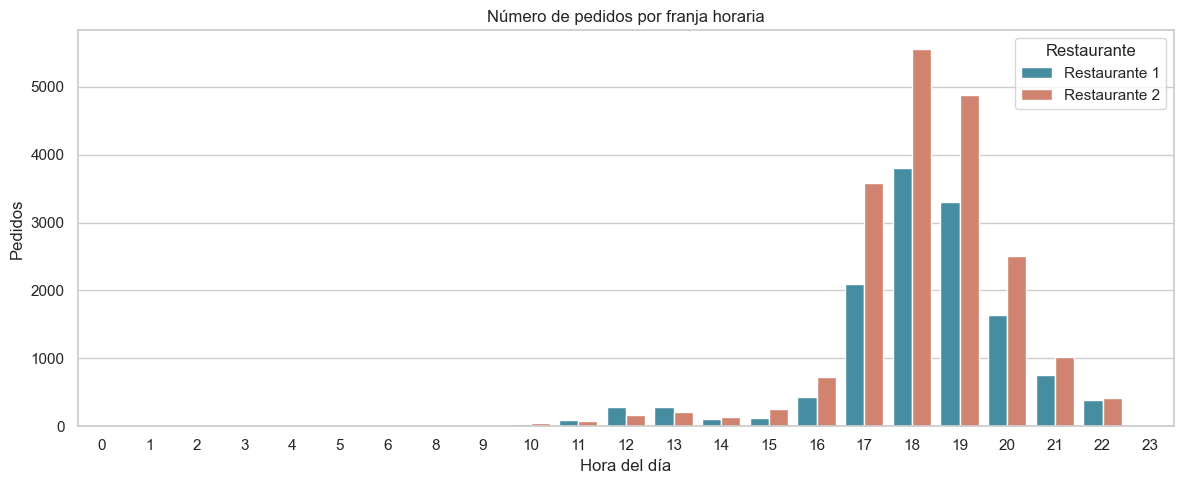

In [9]:
# Contar pedidos por hora y restaurante
pedidos_hora = (
    orders_total
    .groupby(['hour', 'restaurant_id'])
    .size()
    .reset_index(name='n_pedidos')
)

# Gráfica con barras agrupadas
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=pedidos_hora,
    x='hour',
    y='n_pedidos',
    hue='restaurant_id',
    palette={1: '#3896b0', 2: '#e07a5f'},
    ax=ax
)
ax.set_title('Número de pedidos por franja horaria')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Pedidos')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Restaurante 1', 'Restaurante 2'], title='Restaurante')

plt.tight_layout()
plt.savefig('../../notebooks/fig_london_pedidos_hora.png', dpi=150)
plt.show()

### Observaciones
- Se identifica **un único pico de demanda claro entre las 17h y las 20h**,
  con el máximo a las 18h en ambos restaurantes (unos 3.800 pedidos 
  acumulados en el restaurante 1 y 5.560 en el restaurante 2).
- A diferencia de otros restaurantes, **no hay pico de mediodía**,
  lo que es coherente con los hábitos británicos donde la comida para 
  llevar se asocia principalmente a la cena.
- **Ambos locales operan principalmente entre las 16h y las 22h**, con 
  actividad muy baja en horas de almuerzo.
- La franja horaria es una variable contextual candidata para el modelo, 
  con una concentración de demanda muy marcada en las horas de cena 
  que se mantiene **idéntica en los dos restaurantes**.

### 5.3 Pedidos por mes

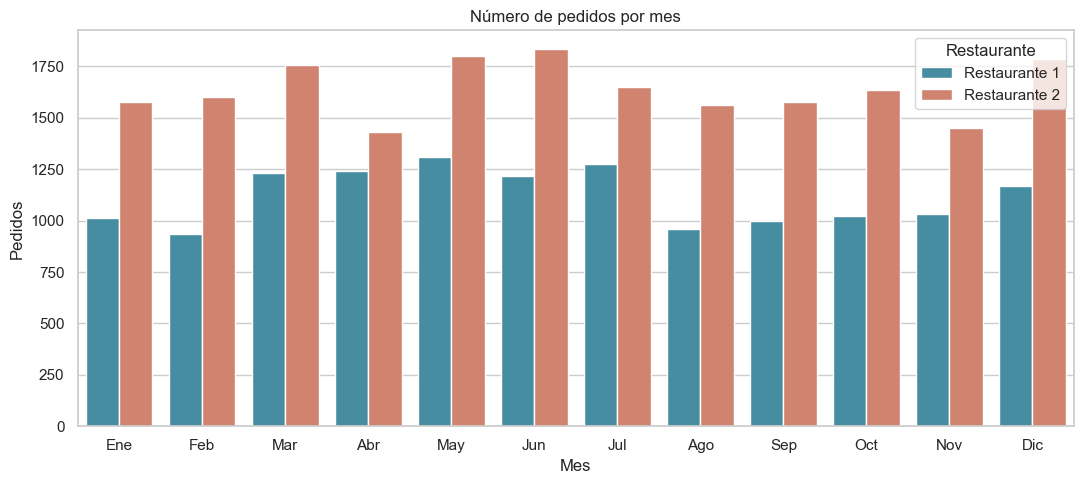

In [10]:
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

# Contar pedidos por mes y restaurante
pedidos_mes = (
    orders_total
    .groupby(['month', 'restaurant_id'])
    .size()
    .reset_index(name='n_pedidos')
)

# Mapear el número del mes a su nombre en español
pedidos_mes['mes_nombre'] = pedidos_mes['month'].map(lambda m: meses[m-1])
pedidos_mes['mes_nombre'] = pd.Categorical(
    pedidos_mes['mes_nombre'],
    categories=meses,
    ordered=True
)

# Gráfica con barras agrupadas
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=pedidos_mes.sort_values('month'),
    x='mes_nombre',
    y='n_pedidos',
    hue='restaurant_id',
    palette={1: '#3896b0', 2: '#e07a5f'},
    ax=ax
)
ax.set_title('Número de pedidos por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Pedidos')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Restaurante 1', 'Restaurante 2'], title='Restaurante')

plt.tight_layout()
plt.savefig('../../notebooks/fig_london_pedidos_mes.png', dpi=150)
plt.show()

### Observaciones
- La demanda mensual presenta una **variación moderada** a lo largo del 
  año en ambos restaurantes, con una diferencia entre el mes más alto y 
  el más bajo de en torno al 30-40%.
- **Los meses de primavera y principios de verano concentran la mayor 
  demanda en ambos restaurantes**, con un máximo en mayo en el 
  restaurante 1 (1.305 pedidos) y en junio en el restaurante 2 
  (1.835 pedidos).
- **Los meses más flojos varían según el restaurante**: febrero (935) y 
  agosto (960) en el restaurante 1, y abril (1.430) y noviembre (1.450) 
  en el restaurante 2.
- Ambos restaurantes muestran un **perfil estacional general similar** 
  con picos en primavera-verano y un repunte en diciembre, lo que 
  confirma que comparten dinámica de negocio aunque con matices propios.

## 6. Serie temporal diaria

Se analiza la evolución del número de pedidos día a día a lo largo 
de todo el periodo. Esta es la variable objetivo que utilizará el 
modelo Prophet para realizar las predicciones.

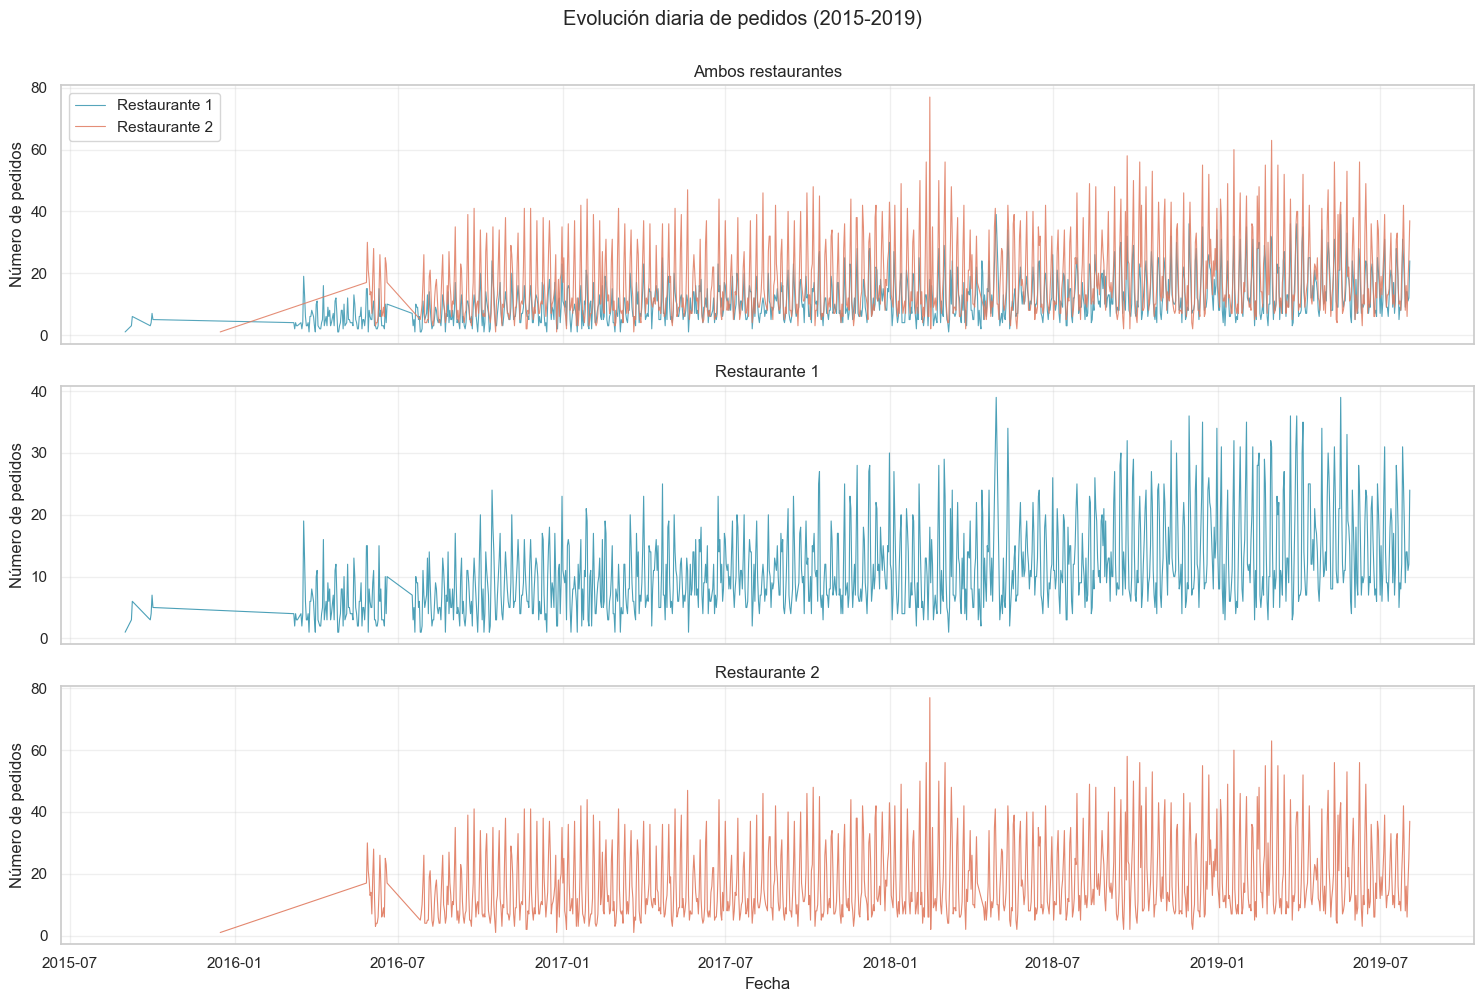

In [11]:
import pandas as pd

# Convertir date a datetime
orders_total['date'] = pd.to_datetime(orders_total['date'])

# Agrupar pedidos por día y restaurante
pedidos_diarios = (
    orders_total
    .groupby(['date', 'restaurant_id'])
    .size()
    .reset_index(name='num_pedidos')
)

# Filtrar las series por restaurante
serie_r1 = pedidos_diarios[pedidos_diarios['restaurant_id'] == 1]
serie_r2 = pedidos_diarios[pedidos_diarios['restaurant_id'] == 2]

# Visualización con tres subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Subplot 1: ambos restaurantes superpuestos
axes[0].plot(serie_r1['date'], serie_r1['num_pedidos'],
             color='#3896b0', linewidth=0.8, alpha=0.85,
             label='Restaurante 1')
axes[0].plot(serie_r2['date'], serie_r2['num_pedidos'],
             color='#e07a5f', linewidth=0.8, alpha=0.85,
             label='Restaurante 2')
axes[0].set_title('Ambos restaurantes')
axes[0].set_ylabel('Número de pedidos')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Restaurante 1
axes[1].plot(serie_r1['date'], serie_r1['num_pedidos'],
             color='#3896b0', linewidth=0.8, alpha=0.9)
axes[1].set_title('Restaurante 1')
axes[1].set_ylabel('Número de pedidos')
axes[1].grid(True, alpha=0.3)

# Subplot 3: Restaurante 2
axes[2].plot(serie_r2['date'], serie_r2['num_pedidos'],
             color='#e07a5f', linewidth=0.8, alpha=0.9)
axes[2].set_title('Restaurante 2')
axes[2].set_ylabel('Número de pedidos')
axes[2].grid(True, alpha=0.3)

axes[2].set_xlabel('Fecha')
fig.suptitle('Evolución diaria de pedidos (2015-2019)', y=1.00)

plt.tight_layout()
plt.savefig('../../notebooks/fig_london_serie_temporal_diaria.png', dpi=150)
plt.show()

### Observaciones
- Ambas series presentan una **tendencia ascendente** a lo largo de los 
  cuatro años, más pronunciada en el restaurante 1 y más moderada en el restaurante 2.
- La fase de arranque (de finales de 2015 a mediados de 2016) muestra 
  pedidos esporádicos en ambos casos. A partir de 2017 las series se 
  estabilizan con patrones semanales claramente visibles.
- Destaca un **pico extraordinario** en el restaurante 2 el 14 de 
  febrero de 2018, con 77 pedidos en un solo día frente a una media 
  habitual cercana a la veintena, correspondiente a San Valentín. 
  Este tipo de eventos refuerza la importancia de incorporar variables 
  contextuales al modelo.
- Se aprecian **caídas puntuales a cero o casi cero** en días concretos 
  como el 25 de diciembre, que probablemente corresponden al cierre del 
  local en festivos señalados.
- Ambas series cumplen las condiciones para constituir la variable objetivo `y` que utiliza 
  Prophet para entrenar el modelo predictivo en cada restaurante.